<a href="https://colab.research.google.com/github/Dvitee/Task-3/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Task 3: Linear Regression - House Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:

# 1. Load and preprocess the dataset
df = pd.read_csv("Housing.csv")  # Replace with the correct path to your file
df = df.dropna()  # Drop missing values for simplicity

In [3]:
# Convert binary categorical features to numeric (0 = no, 1 = yes)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))


In [4]:
# One-hot encode multi-class categorical feature: 'furnishingstatus'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [5]:
# 2. SIMPLE Linear Regression — area → price (for plot)
X_simple = df[['area']]
y = df['price']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
y_pred_s = model_simple.predict(X_test_s)

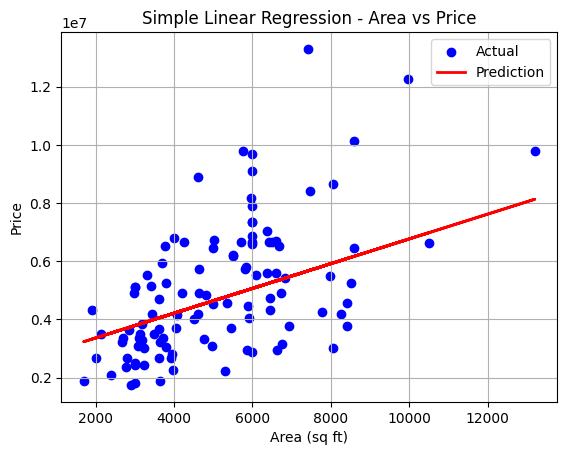

In [6]:
# Plotting simple regression line
plt.scatter(X_test_s, y_test_s, color='blue', label='Actual')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Prediction')
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Simple Linear Regression - Area vs Price")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# 3. MULTIPLE Linear Regression
X_multi = df.drop(columns=['price'])  # Use all other columns as features
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred = model_multi.predict(X_test)

In [8]:
# 4. Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("----- Evaluation Metrics -----")
print("MAE: ₹", round(mae, 2))
print("MSE: ₹", round(mse, 2))
print("R² Score:", round(r2, 4))

----- Evaluation Metrics -----
MAE: ₹ 970043.4
MSE: ₹ 1754318687330.66
R² Score: 0.6529


In [9]:
# 5. Coefficient interpretation
print("\n----- Feature Coefficients -----")
coeff_df = pd.DataFrame(model_multi.coef_, index=X_multi.columns, columns=["Coefficient"])
print(coeff_df)


----- Feature Coefficients -----
                                  Coefficient
area                             2.359688e+02
bedrooms                         7.677870e+04
bathrooms                        1.094445e+06
stories                          4.074766e+05
mainroad                         3.679199e+05
guestroom                        2.316100e+05
basement                         3.902512e+05
hotwaterheating                  6.846499e+05
airconditioning                  7.914267e+05
parking                          2.248419e+05
prefarea                         6.298906e+05
furnishingstatus_semi-furnished -1.268818e+05
furnishingstatus_unfurnished    -4.136451e+05


## 📌 Conclusion

This project explored the use of linear regression to predict housing prices based on various property features.

We started with a simple linear regression model using only the `area` of the property. While this gave us a general upward trend (larger area = higher price), it performed poorly in capturing the overall price variance due to the absence of other influential factors.

We then built a multiple linear regression model incorporating additional numerical and categorical features like `bedrooms`, `bathrooms`, `stories`, `airconditioning`, and `furnishing status`. This significantly improved the model's accuracy:

- **MAE**: ₹9.7 Lakhs
- **MSE**: ₹1.75 Trillion
- **R² Score**: 0.65

The R² value of 0.65 indicates that around 65% of the variability in house prices can be explained by the selected features — a solid result for a basic linear model.

### 🔍 Key Insights from Coefficients:
- Features like `bathrooms`, `airconditioning`, and `hotwaterheating` had the **highest positive impact** on price.
- Unfurnished properties saw the **largest negative impact**, reducing the price by ₹4.1 lakhs on average.
- `area` remains positively correlated with price but is **not the strongest factor**.

This model is a strong baseline and can be further improved by incorporating non-linear methods or more granular location-based data.


# Interview questions

Q1. What assumptions does linear regression make?

Ans- Linear regression makes the following key assumptions:

1. Linearity: The relationship between the independent and dependent variables is linear.

2. Independence: Observations are independent of each other.

3. Homoscedasticity: Constant variance of errors across all levels of the independent variables.

4. Normality of errors: Residuals (errors) are normally distributed.

5. No multicollinearity: Independent variables should not be highly correlated with each other.



Q2. How do you interpret the coefficients?

Each coefficient tells us how much the target variable (e.g., price) changes for a 1-unit increase in the corresponding feature, holding all other features constant.

Example: If the coefficient for area is 236, it means each additional square foot increases the price by ₹236 (assuming other variables are unchanged).

Q3. What is R² score and its significance?

R² (R-squared) is the coefficient of determination.

It represents the proportion of variance in the dependent variable that is explained by the independent variables.

Ranges from 0 to 1:

0 = model explains nothing

1 = perfect prediction

Example: R² = 0.65 means 65% of the variation in house price is explained by the model.

Q4. When would you prefer MSE over MAE?

1. Use MSE when:

You want to penalize larger errors more (due to squaring)

You're optimizing using gradient descent (MSE is differentiable)

2. Use MAE when:

You want a robust metric against outliers

Interpretability matters (MAE is in the same unit as the target)

5. How do you detect multicollinearity?
Multicollinearity occurs when independent variables are highly correlated.

Ways to detect it:

- Correlation matrix: Look for high correlations between features.

- Variance Inflation Factor (VIF): VIF > 5 or 10 indicates multicollinearity.

. What is the difference between simple and multiple regression?

Simple Linear Regression: Uses **one** independent variable to predict the target.

Multiple Linear Regression: Uses **two or more** independent variables.

Example:

- Simple: price ~ area

- Multiple: price ~ area + bedrooms + bathrooms + ...

7. Can linear regression be used for classification?

Technically yes — but it's not ideal.

- Linear regression predicts continuous values, not classes.

- For classification, logistic regression is preferred, as it outputs probabilities (bounded between 0 and 1).

8. What happens if you violate regression assumptions?
Violating assumptions can lead to:

- Biased coefficients

- Inaccurate predictions

- Incorrect confidence intervals

- Over/underestimation of feature importance

Especially important: violating linearity, homoscedasticity, or normality of residuals can reduce trust in the model's results.